In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Hybrid submission

This notebook loads  pretrained Lexicon and RoBERTa models and compares:

1. **Lexicon-only** (LIWC features → LogReg + calibration)
2. **Neural-only** (fine-tuned RoBERTa)
3. **Hybrid A**: calibrated ensemble + meta-classifier
4. **Hybrid B**: confidence-based switching (static threshold tuned on VAL)
5. **Hybrid C**: RL contextual bandit (LinUCB)
6. **Hybrid D**: learned router (classifier) that selects the more reliable model per instance

It also includes:
- **Robustness tests** (test-time perturbations / adversarial masking)
- **Ablation study**
- **Interpretability hooks** (SHAP, Integrated Gradients, hybrid routing analysis)



In [2]:
# Setup
import os, re, json, math, random, warnings
from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd

from sklearn.metrics import precision_recall_fscore_support, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

import joblib

warnings.filterwarnings('ignore')

seed = 42
random.seed(seed)
np.random.seed(seed)

In [3]:
directories = [
    '/content/drive/MyDrive/submission/roberta_final',
    '/content/drive/MyDrive/submission/lexicon_final',
    '/content/drive/MyDrive/submission_data',
    '/content/drive/MyDrive/data_LIWC'
]

for directory in directories:
  print(f"\n Files in {directory}:")
  if os.path.exists(directory):
    for root, _, files in os.walk(directory):
      for file in files:
        print(os.path.join(root, file))
  else:
    print(f"Directory does not exist: {directory}")


 Files in /content/drive/MyDrive/submission/roberta_final:
/content/drive/MyDrive/submission/roberta_final/roberta_submission.csv
/content/drive/MyDrive/submission/roberta_final/roberta_tuned_submission.csv
/content/drive/MyDrive/submission/roberta_final/trainer_state.json
/content/drive/MyDrive/submission/roberta_final/results_roberta.json
/content/drive/MyDrive/submission/roberta_final/val_roberta_tuned_submission.csv
/content/drive/MyDrive/submission/roberta_final/val_roberta_submission.csv
/content/drive/MyDrive/submission/roberta_final/test_roberta_tuned_submission.csv
/content/drive/MyDrive/submission/roberta_final/test_roberta_submission.csv
/content/drive/MyDrive/submission/roberta_final/test_roberta_tuned_submission_RENAMED.csv
/content/drive/MyDrive/submission/roberta_final/best_model/model.safetensors
/content/drive/MyDrive/submission/roberta_final/best_model/config.json
/content/drive/MyDrive/submission/roberta_final/best_model/tokenizer_config.json
/content/drive/MyDrive/

In [4]:
@dataclass
class config:
    train_path: str = "/content/drive/MyDrive/submission_data/train_data.csv"
    val_path:   str = "/content/drive/MyDrive/submission_data/val_data.csv"
    test_path:  str = "/content/drive/MyDrive/submission_data/test_data.csv"

    id_col: str = "row_id"
    text_col: str = "text"
    domain_col: str = "domain"

    labels: Tuple[str, ...] = ("labelanx", "labelanger", "labelsad")
    liwc_cols: Tuple[str, ...] = ("affect","posemo","negemo","anx","anger","sad")
    lexicon_dir: str = "/content/drive/MyDrive/submission/lexicon_final"

    roberta_dir: str = "/content/drive/MyDrive/submission/roberta_final"

    roberta_val_csv: str  = "/content/drive/MyDrive/submission/roberta_final/val_roberta_tuned_submission.csv"
    roberta_test_csv: str = "/content/drive/MyDrive/submission/roberta_final/test_roberta_tuned_submission.csv"

    out_dir: str = "/content/drive/MyDrive/submission/hybrid_submission"

CFG = config()
os.makedirs(config.out_dir, exist_ok=True)

label_map = {
    "label_anx":   "labelanx",
    "label_anger": "labelanger",
    "label_sad":   "labelsad",
}

labels = ["anx", "anger", "sad"]

print("Output directory:", config.out_dir)

Output directory: /content/drive/MyDrive/submission/hybrid_submission


In [5]:
train_df = pd.read_csv(config.train_path)
val_df = pd.read_csv(config.val_path)
test_df = pd.read_csv(config.test_path)

print("Train:",len(train_df))
print("Val:",len(val_df))
print("Test:",len(test_df))
print("Columns:", list(train_df.columns)[:15], "...")

base_keep = [config.id_col, config.text_col, config.domain_col]
for c in ("dataset_name"):
    if c in train_df.columns and c not in base_keep:
        base_keep.append(c)

needed_cols = list(dict.fromkeys(base_keep + list(config.labels) + list(config.liwc_cols)))

train_df = train_df[[col for col in needed_cols if col in train_df.columns]].copy()
val_df = val_df[[col for col in needed_cols if col in val_df.columns]].copy()
test_df = test_df[[col for col in needed_cols if col in test_df.columns]].copy()

# sanity
assert config.id_col in train_df.columns
assert config.id_col in val_df.columns
assert config.id_col in test_df.columns

Train: 24169
Val: 6000
Test: 30008
Columns: ['text', 'dataset_name', 'domain', 'labelanx', 'labelanger', 'labelsad', 'row_id', 'A', 'AE', 'AH', 'AL', 'AM', 'AN', 'AQ', 'AR'] ...


Pretrained baselines

- **Lexicon**: loading the calibrated model per label from `lexicon_final/<label_*>/calibrated_model.joblib`
- **RoBERTa**: loading HuggingFace model from `roberta_final/best_model` (and tokenizer) for inference.

1. **Lexicon-only** (LIWC features → LogReg + calibration)

In [6]:
# Lexicon models
# Directory structure: config.lexicon_dir/label_anx/calibrated_model.joblib

lex_models = {}
for label in labels:
  full_label = f"label_{label}"
  dir = os.path.join(config.lexicon_dir, full_label)
  path = os.path.join(dir, "calibrated_model.joblib")
  if not os.path.exists(path):
    print(f"Missing lexicon model: {path}")
    continue
  lex_models[label] = joblib.load(path)
  print(f"Loaded lexicon model for {label}: {path}")

Loaded lexicon model for anx: /content/drive/MyDrive/submission/lexicon_final/label_anx/calibrated_model.joblib
Loaded lexicon model for anger: /content/drive/MyDrive/submission/lexicon_final/label_anger/calibrated_model.joblib
Loaded lexicon model for sad: /content/drive/MyDrive/submission/lexicon_final/label_sad/calibrated_model.joblib


2. **Neural-only** (fine-tuned RoBERTa)


In [7]:
# Transformer model
transformer_interface = True
if transformer_interface:
  import torch
  from transformers import AutoTokenizer, AutoModelForSequenceClassification

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  model_path = os.path.join(config.roberta_dir, "best_model")
  tok_path = os.path.join(config.roberta_dir, "tokenizer")

  if not os.path.exists(model_path):
    print(f"Missing RoBERTa model: {model_path}")

  tokenizer = AutoTokenizer.from_pretrained(tok_path)
  roberta = AutoModelForSequenceClassification.from_pretrained(model_path, attn_implementation='eager')
  roberta.to(device)
  roberta.eval()

  print("Transformer loaded on:", device)
else:
  print("Transformer interface is missing.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Transformer loaded on: cuda


In [8]:
def sigm(x):
  return 1/(1+np.exp(-x))

def eval_binary(y_true, y_pred):
  p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
  return float(p), float(r), float(f)

def calculate_f1_score(y_true, y_pred):
  p, r, f, _ = precision_recall_fscore_support(
      y_true, y_pred,
      average="binary",
      zero_division=0
  )
  return float(p), float(r), float(f)

def macro_f1(f1_scores):
  return float(np.mean(f1_scores))

def predict_lexicon(df: pd.DataFrame, label:str) -> Tuple[np.ndarray, np.ndarray]:
  x = df[list(config.liwc_cols)].copy()
  prob = lex_models[label].predict_proba(x)[:,1].astype(np.float32)
  pred = (prob >= 0.5).astype(int)
  return prob,pred

def predict_roberta_probs(df: pd.DataFrame, batch_size: int=32) -> np.ndarray:
  import torch
  probs_all = []
  texts = df[config.text_col].astype(str).tolist()

  for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    enc = tokenizer(batch, padding=True, truncation= True, max_length = 256, return_tensors= "pt").to(device)
    with torch.no_grad():
      out = roberta(**enc).logits
      probs = torch.sigmoid(out).detach().cpu().numpy().astype(np.float32)
    probs_all.append(probs)

  return np.vstack(probs_all)

def attach_baseline_preds(val_df: pd.DataFrame, test_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
  v = val_df.copy()
  t = test_df.copy()

  for label in labels:
    prob_v, pred_v = predict_lexicon(v, label)
    prob_t, pred_t = predict_lexicon(t, label)

    v[f"lex_{label}_prob"] = prob_v
    v[f"lex_{label}_pred"] = pred_v
    t[f"lex_{label}_prob"] = prob_t
    t[f"lex_{label}_pred"] = pred_t
  if transformer_interface:
    probs_val = predict_roberta_probs(v)
    probs_test = predict_roberta_probs(t)

    for i, pred_col, in enumerate(config.labels):
      short = {"labelanx": "anx", "labelanger": "anger", "labelsad": "sad"}[pred_col]
      v[f"roberta_{short}_prob"] = probs_val[:,i]
      v[f"roberta_{short}_pred"] = (probs_val[:,i] >= 0.5).astype(int)
      t[f"roberta_{short}_prob"] = probs_test[:,i]
      t[f"roberta_{short}_pred"] = (probs_test[:,i] >= 0.5).astype(int)
  else:
    val_pred = pd.read_csv(config.roberta_val_csv)
    test_pred = pd.read_csv(config.roberta_test_csv)
    v = v.merge(val_pred, on=config.id_col, how="left", suffixes=("","_rb"))
    t = t.merge(test_pred, on=config.id_col, how = "left", suffixes=("","_rb"))

    for pred_col in config.labels:
      short = {"labelanx": "anx", "labelanger": "anger", "labelsad": "sad"}[pred_col]
      v[f"roberta_{short}_prob"] = v[f"val_roberta_tuned_{pred_col}_prob"].astype(np.float32)
      v[f"roberta_{short}_pred"] = v[f"val_roberta_tuned_{pred_col}_pred"].astype(int)
      t[f"roberta_{short}_prob"] = t[f"test_roberta_tuned_{pred_col}_prob"].astype(np.float32)
      t[f"roberta_{short}_pred"] = t[f"test_roberta_tuned_{pred_col}_pred"].astype(int)

  return v, t

val_full, test_full = attach_baseline_preds(val_df, test_df)

In [9]:
print("val_full columns sample:", [col for col in val_full.columns if col.startswith(('lex_', 'roberta_'))][:10])

val_full columns sample: ['lex_anx_prob', 'lex_anx_pred', 'lex_anger_prob', 'lex_anger_pred', 'lex_sad_prob', 'lex_sad_pred', 'roberta_anx_prob', 'roberta_anx_pred', 'roberta_anger_prob', 'roberta_anger_pred']


In [10]:
# Hybrid Justification
roberta_df = test_full.copy()
lexicon_path = config.lexicon_dir

# combined lexicon df (3 files to 1)
lex_full = None
for current_label in labels:
    lex_dir_name = f"label_{current_label}"
    lex_prefix = label_map[f"label_{current_label}"] # convert 'label_anx' to 'labelanx'

    path = os.path.join(lexicon_path, lex_dir_name, "test_predictions.csv")
    df_lex = pd.read_csv(path)

    needed_lex = ["row_id", f"{lex_prefix}_pred_policy"]
    missing_lex = [col for col in needed_lex if col not in df_lex.columns]
    if missing_lex:
        print(f"Missing columns in lexicon file: {missing_lex} for label {current_label}.")

    df_lex = df_lex[needed_lex].rename(columns={f"{lex_prefix}_pred_policy": f"lex_{current_label}_pred_policy"})
    lex_full = df_lex if lex_full is None else lex_full.merge(df_lex, on="row_id", how="inner")

# merging roberta predictions with lexicon
df = roberta_df.merge(lex_full, on="row_id", how="inner")

print("\nMerged CSV columns containing 'pred':")
print([col for col in df.columns if "pred" in col][:50])

def analyze_label(label_short):
    label_full = f"label{label_short}" # e.g., 'label_anx'
    pred_col = label_full
    roberta_pred_col = f"roberta_{label_short}_pred"
    lex_pred_col = f"lex_{label_short}_pred_policy"

    has_label = df[pred_col].notna()
    y = df.loc[has_label, pred_col].astype(int)
    pred_roberta = df.loc[has_label, roberta_pred_col].astype(int)
    pred_lex = df.loc[has_label, lex_pred_col].astype(int)

    roberta_correct = (pred_roberta == y)
    lex_correct = (pred_lex == y)

    both_correct = int((roberta_correct & lex_correct).sum())
    both_wrong = int((~roberta_correct & ~lex_correct).sum())
    roberta_only_correct = int((roberta_correct & ~lex_correct).sum())
    lex_only_correct = int((~roberta_correct & lex_correct).sum())
    total = len(y)

    print(f"Label: {label_full}")
    print(f"RoBERTa pred col: {roberta_pred_col}")
    print(f"Lexicon pred col: {lex_pred_col}")
    print(f"Both correct:         {both_correct} ({both_correct/total:.3f})")
    print(f"Both wrong:           {both_wrong} ({both_wrong/total:.3f})")
    print(f"RoBERTa only correct: {roberta_only_correct} ({roberta_only_correct/total:.3f})")
    print(f"Lexicon only correct: {lex_only_correct} ({lex_only_correct/total:.3f})")

for current_label in labels:
    analyze_label(current_label)


Merged CSV columns containing 'pred':
['lex_anx_pred', 'lex_anger_pred', 'lex_sad_pred', 'roberta_anx_pred', 'roberta_anger_pred', 'roberta_sad_pred', 'lex_anx_pred_policy', 'lex_anger_pred_policy', 'lex_sad_pred_policy']
Label: labelanx
RoBERTa pred col: roberta_anx_pred
Lexicon pred col: lex_anx_pred_policy
Both correct:         22567 (0.749)
Both wrong:           155 (0.005)
RoBERTa only correct: 3949 (0.131)
Lexicon only correct: 3449 (0.115)
Label: labelanger
RoBERTa pred col: roberta_anger_pred
Lexicon pred col: lex_anger_pred_policy
Both correct:         21824 (0.725)
Both wrong:           150 (0.005)
RoBERTa only correct: 3648 (0.121)
Lexicon only correct: 4498 (0.149)
Label: labelsad
RoBERTa pred col: roberta_sad_pred
Lexicon pred col: lex_sad_pred_policy
Both correct:         23622 (0.784)
Both wrong:           126 (0.004)
RoBERTa only correct: 4909 (0.163)
Lexicon only correct: 1463 (0.049)


In [11]:
# Baseline evaluation
rows = []
for lab in labels:
    full_label = f"label_{lab}"
    pred_col = label_map[full_label]

    # Lexicon
    mask = val_full[pred_col].notna()
    y_true = val_full.loc[mask, pred_col].astype(int).to_numpy()
    y_pred = val_full.loc[mask, f"lex_{lab}_pred"].astype(int).to_numpy()
    p,r,f = eval_binary(y_true, y_pred)
    rows.append({"split":"VAL","model":"Lexicon","label":lab,"precision":p,"recall":r,"f1":f})

    # Transformer
    y_pred = val_full.loc[mask, f"roberta_{lab}_pred"].astype(int).to_numpy()
    p,r,f = eval_binary(y_true, y_pred)
    rows.append({"split":"VAL","model":"Transformer","label":lab,"precision":p,"recall":r,"f1":f})

# Test
for lab in labels:
    full_label = f"label_{lab}"
    pred_col = label_map[full_label]
    mask = test_full[pred_col].notna()
    y_true = test_full.loc[mask, pred_col].astype(int).to_numpy()

    y_pred = test_full.loc[mask, f"lex_{lab}_pred"].astype(int).to_numpy()
    p,r,f = eval_binary(y_true, y_pred)
    rows.append({"split":"TEST","model":"Lexicon","label":lab,"precision":p,"recall":r,"f1":f})

    y_pred = test_full.loc[mask, f"roberta_{lab}_pred"].astype(int).to_numpy()
    p,r,f = eval_binary(y_true, y_pred)
    rows.append({"split":"TEST","model":"Transformer","label":lab,"precision":p,"recall":r,"f1":f})

base_metrics = pd.DataFrame(rows)
base_metrics.to_csv(os.path.join(config.out_dir, "baseline_metrics.csv"), index=False)
base_metrics

,split,model,label,precision,recall,f1
0,VAL,Lexicon,anx,1.000000,0.051225,0.097458
1,VAL,Transformer,anx,0.959551,0.951002,0.955257
2,VAL,Lexicon,anger,0.083333,0.006678,0.012365
3,VAL,Transformer,anger,0.975951,0.971063,0.973501
4,VAL,Lexicon,sad,0.027778,0.002041,0.003802
5,VAL,Transformer,sad,0.968685,0.946939,0.957688
6,TEST,Lexicon,anx,1.000000,0.072591,0.135357
7,TEST,Transformer,anx,0.923333,0.450846,0.605862
8,TEST,Lexicon,anger,0.080625,0.021383,0.033802
9,TEST,Transformer,anger,0.918643,0.540803,0.680813


3. **Hybrid A**: calibrated ensemble + meta-classifier

In [12]:
# Hybrid A: Stacking (simple ensemble)
def train_hybrid_A(val_df:pd.DataFrame, label:str, C=1.0, class_weight = "balanced", random_state = 42):
  pred_col = label_map[f"label_{label}"]
  mask = val_df[pred_col].notna()

  x = val_df.loc[mask, [f"roberta_{label}_prob", f"lex_{label}_prob"]].to_numpy(dtype=float)
  y = val_df.loc[mask, pred_col].astype(int).to_numpy()

  meta_model = LogisticRegression(
      C=C,
      solver="lbfgs",
      max_iter=1000,
      class_weight=class_weight,
      random_state=random_state
  )
  meta_model.fit(x,y)

  return(meta_model)

def predict_hybrid_A(df:pd.DataFrame, label:str, meta_model, thr = 0.5):
  x = df[[f"roberta_{label}_prob", f"lex_{label}_prob"]].to_numpy(dtype=float)

  probability = meta_model.predict_proba(x)[:,1]
  prediction = (probability >= thr).astype(int)

  return probability, prediction

hyA_models = {label: train_hybrid_A(val_full, label, C=1.0) for label in labels}

rows=[]
for split_name, df in [("VAL", val_full), ("TEST", test_full)]:
    for label in labels:
        pred_col = label_map[f"label_{label}"]
        mask = df[pred_col].notna()
        y_true = df.loc[mask, pred_col].astype(int).to_numpy()
        prob, pred = predict_hybrid_A(df, label, hyA_models[label])
        p_,r_,f_ = eval_binary(y_true, pred[mask.to_numpy()])
        rows.append({"split":split_name,"model":"HybridA_meta","label":label,"precision":p_,"recall":r_,"f1":f_})

hyA_metrics = pd.DataFrame(rows)
hyA_metrics.to_csv(os.path.join(config.out_dir, "hybridA_metrics.csv"), index=False)
hyA_metrics

,split,model,label,precision,recall,f1
0,VAL,HybridA_meta,anx,0.957589,0.955457,0.956522
1,VAL,HybridA_meta,anger,0.974316,0.971063,0.972687
2,VAL,HybridA_meta,sad,0.962656,0.946939,0.954733
3,TEST,HybridA_meta,anx,0.923671,0.466797,0.620175
4,TEST,HybridA_meta,anger,0.918394,0.541458,0.681263
5,TEST,HybridA_meta,sad,0.863309,0.578406,0.692707


4. **Hybrid B**: confidence-based switching (static threshold tuned on VAL)

Idea: use RoBERTa confidence |pT-0.5|
- If confidence is high: trust Transformer
- If confidence is low: fall back to Lexicon

Tuned the confidence threshold on VAL per label to maximize F1.


In [13]:
from operator import le
# Hybrid B: confidense-based switching

def thr_hybrid_B(val_df: pd.DataFrame, label:str, thresholds = None):
  if thresholds is None:
    thresholds = np.linspace(0,1,11)

  pred_col = label_map[f"label_{label}"]
  mask = val_df[pred_col].notna()
  y_true = val_df.loc[mask, pred_col].astype(int).to_numpy()

  roberta_prob = val_df[f"roberta_{label}_prob"].astype(float).to_numpy(dtype = float)
  roberta_pred = val_df.loc[mask,f"roberta_{label}_pred"].astype(int).to_numpy()
  lexicon_pred = val_df.loc[mask,f"lex_{label}_pred"].astype(int).to_numpy()

  roberta_confidence = np.abs(roberta_prob - 0.5)

  best_thr = 0.0
  best_f1 = -1.0

  for thr in thresholds:
    combined_preds = np.where(roberta_confidence >= thr,
                              roberta_pred, lexicon_pred)
    precision, recall, f1 = calculate_f1_score(y_true, combined_preds)
    if f1 > best_f1:
      best_thr = float(thr)
      best_f1 = f1

  return best_thr, best_f1

def predict_hybrid_B(df:pd.DataFrame, label:str, thr:float):
  pred_col = label_map[f"label_{label}"]
  roberta_probs = df[f"roberta_{label}_prob"].astype(float).to_numpy(dtype = float)
  roberta_confidence = np.abs(roberta_probs - 0.5)

  roberta_pred_all = df[f"roberta_{label}_pred"].astype(int).to_numpy()
  lexicon_pred_all = df[f"lex_{label}_pred"].astype(int).to_numpy()

  predictions = np.where(
      roberta_confidence >= thr,
      roberta_pred_all,
      lexicon_pred_all
  )
  return predictions.astype(int)

hyB_thr = {}
for label in labels:
    thr, f1v = thr_hybrid_B(val_full, label)
    hyB_thr[label] = thr
    print(f"[HybridB] {label:>10} | best thr={thr:.3f} | VAL F1={f1v:.4f}")

rows=[]
for split_name, df_loop in [("VAL", val_full), ("TEST", test_full)]:
    for label in labels:
        pred_col = label_map[f"label_{label}"]
        mask = df_loop[pred_col].notna()
        y_true = df_loop.loc[mask, pred_col].astype(int).to_numpy()
        y_pred_all = predict_hybrid_B(df_loop, label, hyB_thr[label])
        y_pred = y_pred_all[mask.to_numpy()]
        p,r,f = eval_binary(y_true, y_pred)
        rows.append({"split":split_name,"model":"HybridB_switch","label":label,"precision":p,"recall":r,"f1":f})

hyB_metrics = pd.DataFrame(rows)
hyB_metrics.to_csv(os.path.join(config.out_dir, "hybridB_switch_metrics.csv"), index=False)
hyB_metrics

[HybridB]        anx | best thr=0.400 | VAL F1=0.9626
[HybridB]      anger | best thr=0.300 | VAL F1=0.9768
[HybridB]        sad | best thr=0.300 | VAL F1=0.9626


,split,model,label,precision,recall,f1
0,VAL,HybridB_switch,anx,0.979263,0.946548,0.962627
1,VAL,HybridB_switch,anger,0.983089,0.970506,0.976757
2,VAL,HybridB_switch,sad,0.980932,0.944898,0.962578
3,TEST,HybridB_switch,anx,0.934805,0.448079,0.605787
4,TEST,HybridB_switch,anger,0.922517,0.539057,0.680485
5,TEST,HybridB_switch,sad,0.875367,0.575514,0.694455


5. **Hybrid C**: RL contextual bandit (LinUCB)
***
Acions:
- 0 = choose RoBERTa
- 1 = choose Lexicon
***

- Reward = 1 if chosen model prediction == y_true else 0
- d: number of features in context vector, in this case 2 for [roberta_prob, confidence]
- alpha = 0: always chooses what seems best
- alpha = 2: tries uncertain actions more
- self.A: covariance matrices, one for each action
- self.b: reward vectors

In [14]:
# Hybrid C: Contextual BAndit (LinUCB router)

class LinUCB:

  def __init__(self, d, alpha = 1.0, n_actions =2):
    self.d = d
    self.alpha = alpha
    self.n_actions = n_actions
    self.a = [np.eye(d)for _ in range(n_actions)]
    self.b = [np.zeros(d) for _ in range(n_actions)]

  def choose(self, context):
    context = context.reshape(-1)
    best_action, best_score = 0, -1e18

    best_p = -float('inf')
    best_a = -1

    for action in range(self.n_actions):
      a_inv = np.linalg.inv(self.a[action])
      theta = a_inv @ self.b[action]
      mean = float(theta @ context) #exploitation
      uncertainty = float(np.sqrt(context @ a_inv @ context)) #exploration
      ucb_score = mean + self.alpha * uncertainty # upper confidence bound

      if ucb_score > best_p:
        best_p = ucb_score
        best_a = action

    return best_a

  def update(self,action,context,reward):
    context = context.reshape(-1)
    self.a[action] += np.outer(context,context)
    self.b[action] += reward* context


def get_bandit_features(df, label) -> np.ndarray:
  roberta_probs = df[f"roberta_{label}_prob"].fillna(0.0).to_numpy(dtype = float)
  lexicon_probs = df[f"lex_{label}_prob"].fillna(0.0).to_numpy(dtype = float)

  confidence_r = np.abs( roberta_probs - 0.5)
  confidence_l = np.abs(lexicon_probs - 0.5)

  roberta_pred = df[f"roberta_{label}_pred"].astype(int).to_numpy()
  lexicon_pred = df[f"lex_{label}_pred"].astype(int).to_numpy()
  disagreement = (roberta_pred != lexicon_pred).astype(float)
  features = np.column_stack([roberta_probs, confidence_r, lexicon_probs, confidence_l, disagreement]).astype(float)

  return features

def train_hybrid_C(val_df_with_preds, label, alpha=1.0):
  pred_col = label_map[f"label_{label}"]
  mask = val_df_with_preds[pred_col].notna()
  sub = val_df_with_preds.loc[mask].copy()

  y_true = sub[pred_col].astype(int).to_numpy()
  roberta_pred = sub[f"roberta_{label}_pred"].astype(int).to_numpy()
  lexicon_pred = sub[f"lex_{label}_pred"].astype(int).to_numpy()

  x_features = get_bandit_features(sub, label)
  bandit = LinUCB(d=x_features.shape[1], alpha=alpha,  n_actions=2)

  for i in range(len(y_true)):
      context = x_features[i]
      chosen_action = bandit.choose(context)
      chosen_pred = roberta_pred[i] if chosen_action == 0 else lexicon_pred[i]
      reward = int(chosen_pred == y_true[i])
      bandit.update(chosen_action, context, reward)

  return bandit

def predict_hybrid_C(df_with_preds, label, bandit):
    x_features = get_bandit_features(df_with_preds, label)

    roberta_pred = df_with_preds[f"roberta_{label}_pred"].astype(int).to_numpy()
    lexicon_pred = df_with_preds[f"lex_{label}_pred"].astype(int).to_numpy()

    n_samples = len(df_with_preds)
    actions = np.zeros(n_samples, dtype=int)
    predictions = np.zeros(n_samples, dtype=int)

    for i in range(n_samples):
        context = x_features[i]

        action = bandit.choose(context)
        actions[i] = action

        predictions[i] = roberta_pred[i] if action == 0 else lexicon_pred[i]

    return predictions, actions


bandit_models = {}
for label in labels:
    bandit_models[label] = train_hybrid_C(val_full, label, alpha=1.0)

rows = []
action_distributions = {}

for split_name, df_loop in [("Val:", val_full), ("Test:", test_full)]:
    for label in labels:
        pred_col = label_map[f"label_{label}"]
        mask = df_loop[pred_col].notna()
        y_true = df_loop.loc[mask, pred_col].astype(int).to_numpy()

        predictions, actions = predict_hybrid_C(df_loop, label, bandit_models[label])
        predictions_masked = predictions[mask.to_numpy()]

        precision, recall, f1 = calculate_f1_score(y_true, predictions_masked)
        rows.append({
            "split": split_name,
            "model": "HybridC_bandit",
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

# action distribution by domain on test set
for label in labels:
    predictions, actions = predict_hybrid_C(test_full, label, bandit_models[label])

    action_dist = test_full[[CFG.domain_col]].copy()
    action_dist["picked_roberta"] = (actions == 0).astype(int)
    action_dist["picked_lexicon"] = (actions == 1).astype(int)

    distribution = action_dist.groupby(CFG.domain_col)[["picked_roberta", "picked_lexicon"]].mean().reset_index()
    distribution["picked_roberta_pct"] = (100 * distribution["picked_roberta"]).round(2)
    distribution["picked_lexicon_pct"] = (100 * distribution["picked_lexicon"]).round(2)

    action_distributions[label] = distribution

bandit_metrics = pd.DataFrame(rows)
bandit_metrics.to_csv(os.path.join(CFG.out_dir, "hybridC_bandit_metrics.csv"), index=False)


6. **Hybrid D**: learned router (classifier) that selects the more reliable model per instance
***

Router features (per instance):
`[pT, |pT-0.5|, pL, |pL-0.5|, disagreement]`

Target is based on correctness on VAL:
- If only one model is correct: learn to pick that one
- If both correct/both wrong: tie-breaker defaults to Transformer


In [15]:
# Hybrid D: Learned router

def get_router_features(df, label) -> np.ndarray:
  roberta_probs = df[f"roberta_{label}_prob"].fillna(0.0).to_numpy(dtype = float)
  lexicon_probs = df[f"lex_{label}_prob"].fillna(0.0).to_numpy(dtype = float)

  confidence_r = np.abs( roberta_probs - 0.5)
  confidence_l = np.abs(lexicon_probs - 0.5)

  roberta_pred = df[f"roberta_{label}_pred"].astype(int).to_numpy()
  lexicon_pred = df[f"lex_{label}_pred"].astype(int).to_numpy()
  disagreement = (roberta_pred != lexicon_pred).astype(float)
  features = np.column_stack([roberta_probs, confidence_r, lexicon_probs, confidence_l, disagreement]).astype(float)
  return features

def train_hybrid_D(val_df_with_preds, label, tie_breaker = "T"):
  pred_col = label_map[f"label_{label}"]
  mask = val_df_with_preds[pred_col].notna()
  sub = val_df_with_preds.loc[mask].copy()

  y_true = sub[pred_col].astype(int).to_numpy()
  roberta_pred = sub[f"roberta_{label}_pred"].astype(int).to_numpy()
  lexicon_pred = sub[f"lex_{label}_pred"].astype(int).to_numpy()

  roberta_correct = (roberta_pred == y_true)
  lexicon_correct = (lexicon_pred == y_true)

  router_target = np.zeros_like(y_true, dtype = int)

  # tie
  if tie_breaker == "T":
    router_target[(roberta_correct & lexicon_correct)] = 1
    router_target[(~roberta_correct & ~lexicon_correct)] = 1
  elif tie_breaker == "L":
    router_target[(roberta_correct & lexicon_correct)] = 0
    router_target[(~roberta_correct & ~lexicon_correct)] = 0
  else:
    raise ValueError("tie_breaker must be 'T' or 'L'")

  x = get_router_features(sub, label)

  router = LogisticRegression(max_iter=2000, class_weight ="balanced", random_state=42)
  router.fit(x, router_target)

  return router

def predict_hybrid_D(df_with_preds, label, router):
  X = get_router_features(df_with_preds, label)
  use_lexicon = router.predict(X).astype(int)

  roberta_pred = df_with_preds[f"roberta_{label}_pred"].astype(int).to_numpy()
  lexicon_pred = df_with_preds[f"lex_{label}_pred"].astype(int).to_numpy()

  predictions = np.where(
    use_lexicon == 1,
    lexicon_pred,
    roberta_pred
  )
  return predictions, use_lexicon

hybrid_models = {}
for label in labels:
    hybrid_models[label] = train_hybrid_D(val_full, label, tie_breaker="T")

rows = []
action_distributions = {}

for split_name, df_loop in [("Val:", val_full), ("Test:", test_full)]:
    for label in labels:
        pred_col = label_map[f"label_{label}"]
        mask = df_loop[pred_col].notna()
        y_true = df_loop.loc[mask, pred_col].astype(int).to_numpy()

        predictions, actions = predict_hybrid_D(df_loop, label, hybrid_models[label])
        predictions_masked = predictions[mask.to_numpy()]

        precision, recall, f1 = calculate_f1_score(y_true, predictions_masked)
        rows.append({
            "split": split_name,
            "model": "HybridD_router",
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

for label in labels:
    predictions, actions = predict_hybrid_D(test_full, label, hybrid_models[label])

    action_dist = test_full[[CFG.domain_col]].copy()
    action_dist["picked_roberta"] = (actions == 0).astype(int)
    action_dist["picked_lexicon"] = (actions == 1).astype(int)

    distribution = action_dist.groupby(CFG.domain_col)[["picked_roberta", "picked_lexicon"]].mean().reset_index()
    distribution["picked_roberta_pct"] = (100 * distribution["picked_roberta"]).round(2)
    distribution["picked_lexicon_pct"] = (100 * distribution["picked_lexicon"]).round(2)

    action_distributions[label] = distribution

# metrics
hybrid_metrics = pd.DataFrame(rows)
hybrid_metrics.to_csv(os.path.join(CFG.out_dir, "hybridD_router_metrics.csv"), index=False)

In [16]:
def evaluate_on_split(df, split_name, prediction_function):
    all_results = []
    f1_scores = []

    for emotion in labels:
        pred_col = label_map[f"label_{emotion}"]

        has_label = df[pred_col].notna()
        y_true = df.loc[has_label, pred_col].astype(int).to_numpy()

        all_predictions = prediction_function(emotion)
        y_pred = all_predictions[has_label]

        precision, recall, f1 = eval_binary(y_true, y_pred)

        all_results.append({
            "Dataset": split_name,
            "Emotion": emotion,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })
        f1_scores.append(f1)

    return pd.DataFrame(all_results), macro_f1(f1_scores)


def make_summary_row(eval_df, macro_f1):
    summary = {
        "Model": eval_df["Dataset"].iloc[0],
        "Macro F1": macro_f1
    }

    for emotion in labels:
        emotion_f1 = eval_df.loc[eval_df["Emotion"] == emotion, "F1"].iloc[0]
        summary[f"{emotion} F1"] = float(emotion_f1)

    return summary

In [17]:
# Main run
print("Training and evaluating hybrid models")

print("\n[1/5] training meta-models for hybrid A (stacking)")
trained_metas = {}
for emotion in labels:
    trained_metas[emotion] = train_hybrid_A(val_full, emotion)
print("done")

print("\n[2/5] best confidence thresholds for hybrid b")
best_thresholds = {}
for emotion in labels:
    threshold, val_f1 = thr_hybrid_B(val_full, emotion)
    best_thresholds[emotion] = threshold
    print(f"  {emotion}: best threshold = {threshold:.3f} | validation f1 = {val_f1:.4f}")

print("\n[3/5] training contextual bandits for hybrid C")
trained_bandits = {}
for emotion in labels:
    trained_bandits[emotion] = train_hybrid_C (val_full, emotion, alpha=1.0)
print("done")

print("\n[4/5] training routers for hybrid D (learned router)")
trained_routers = {}
for emotion in labels:
    router_model = train_hybrid_D(val_full, emotion, tie_breaker="T")
    trained_routers[emotion] = router_model
print("done")

print("\n[5/5] evaluating models")

all_summaries = []

def eval_on_split(df, split_name, record_routing=False):
    global all_summaries

    print(f"\n{split_name} set results")

    # hybrid a
    results_df, macro = evaluate_on_split(
        df,
        f"{split_name} | hybrid a (stacking)",
        lambda emo: predict_hybrid_A(df, emo, trained_metas[emo])[1]
    )
    all_summaries.append(make_summary_row(results_df, macro))

    # hybrid b
    results_df, macro = evaluate_on_split(
        df,
        f"{split_name} | hybrid b (confidence threshold)",
        lambda emo: predict_hybrid_B(df, emo, best_thresholds[emo])
    )
    all_summaries.append(make_summary_row(results_df, macro))

    # hybrid C (contextual bandit)
    bandit_rates = {}
    def predict_bandit(emo):
        preds, actions = predict_hybrid_C(df, emo, trained_bandits[emo])
        if record_routing:
            bandit_rates[emo] = float(np.mean(actions == 0))  # 0 = roberta
        return preds

    results_df, macro = evaluate_on_split(
        df,
        f"{split_name} | hybrid C (contextual bandit)",
        predict_bandit
    )
    all_summaries.append(make_summary_row(results_df, macro))

    # hybrid D (learned router)
    router_rates = {}
    def predict_router(emo):
        router = trained_routers[emo]
        preds, choices = predict_hybrid_D(df, emo, router)
        if record_routing:
            router_rates[emo] = float(np.mean(choices))
        return preds

    results_df, macro = evaluate_on_split(
        df,
        f"{split_name} | hybrid D (learned router)",
        predict_router
    )
    all_summaries.append(make_summary_row(results_df, macro))


    if record_routing:
        print(f"\nhybrid C routing rates ({split_name}):")
        for emo in labels:
            print(f"  {emo}: {bandit_rates.get(emo, float('nan')):.3f}")

        print(f"\nhybrid D routing rates ({split_name}):")
        for emo in labels:
            print(f"  {emo}: {router_rates.get(emo, float('nan')):.3f}")


# validation (no routing stats)
eval_on_split(val_full, "validation", record_routing=False)

# test (shows routing behaviour)
eval_on_split(test_full, "test", record_routing=True)

print("\nFinal results summary")
summary_table = pd.DataFrame(all_summaries)
summary_table = summary_table[["Model", "anx F1", "anger F1", "sad F1", "Macro F1"]]
print(summary_table.to_string(index=False))

Training and evaluating hybrid models

[1/5] training meta-models for hybrid A (stacking)
done

[2/5] best confidence thresholds for hybrid b
  anx: best threshold = 0.400 | validation f1 = 0.9626
  anger: best threshold = 0.300 | validation f1 = 0.9768
  sad: best threshold = 0.300 | validation f1 = 0.9626

[3/5] training contextual bandits for hybrid C
done

[4/5] training routers for hybrid D (learned router)
done

[5/5] evaluating models

validation set results

test set results

hybrid C routing rates (test):
  anx: 0.997
  anger: 0.996
  sad: 0.998

hybrid D routing rates (test):
  anx: 0.910
  anger: 0.751
  sad: 0.911

Final results summary
                                       Model   anx F1  anger F1   sad F1  Macro F1
            validation | hybrid a (stacking) 0.956522  0.972687 0.954733  0.961314
validation | hybrid b (confidence threshold) 0.962627  0.976757 0.962578  0.967321
   validation | hybrid C (contextual bandit) 0.960541  0.976992 0.962422  0.966652
      valid

## 8) Robustness tests
**Text Perturbations applied:**
- Character-level: random swaps, insertions, and deletions
- Word-level: synonym replacement, random word deletion/insertion
- Sentence-level: syntactic paraphrasing patterns
- Semantic masking: masking or removing lexicon words (LIWC features)

**Evaluation:**
- Re-computed predictions for all models (transformer, lexicon, Hybrid A/B/C)
- Performance metrics (accuracy, precision, recall, F1) compared to clean text
- Robustness scores `(1 - (clean_f1 - perturbed_f1)/clean_f1)`
- Biased examples where models agreed regardless of true label


Based on:
`https://doi.org/10.48550/arXiv.2112.08313`


In [18]:
synonyms = {
    # small but safe
    "good": ["nice","great"],
    "bad": ["awful","terrible"],
    "hate": ["dislike","detest"],
    "love": ["adore","like"],
    "angry": ["mad","furious"],
    "sad": ["unhappy","down"],
    "scared": ["afraid","terrified"],
}

profanity = {"f***","shit","fuck","bitch","asshole","dick","cunt"}

In [20]:
from typing import Dict, Callable, List, Tuple, Optional
from collections import Counter
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

class TextPerturbator:
    def __init__(self, lexicon_words: set, synonym_dict: Dict[str, List[str]], profanity_set: set):
        self.lexicon_words = set(lexicon_words or [])
        self.synonym_dict = synonym_dict or {}
        self.profanity_set = set(profanity_set or [])
        self.word_re = re.compile(r"\b\w+\b")

    def character_swap(self, text: str, p_char: float = 0.05, max_swaps: int = 3) -> str:
        if not isinstance(text, str) or len(text) < 3:
            return text
        chars = list(text)
        idx = [i for i in range(len(chars) - 1) if chars[i].isalpha() and chars[i + 1].isalpha()]
        random.shuffle(idx)
        swaps = 0
        for i in idx:
            if swaps >= max_swaps:
                break
            if random.random() < p_char:
                chars[i], chars[i + 1] = chars[i + 1], chars[i]
                swaps += 1
        return "".join(chars)

    def character_insertion( self, text: str, p_char: float = 0.05,
                            alphabet: str = "abcdefghijklmnopqrstuvwxyz",
                            max_inserts: int = 2) -> str:
        if not isinstance(text, str) or len(text) < 3:
            return text
        chars = list(text)
        pos = list(range(1, len(chars)))
        random.shuffle(pos)
        inserts = 0
        for p in pos:
            if inserts >= max_inserts:
                break
            if random.random() < p_char:
                chars.insert(p, random.choice(alphabet))
                inserts += 1
        return "".join(chars)

    def character_deletion(self, text: str, p_char: float = 0.05, max_deletes: int = 2) -> str:
        if not isinstance(text, str) or len(text) < 3:
            return text
        chars = list(text)
        idx = [i for i in range(1, len(chars) - 1) if chars[i].isalpha()]
        random.shuffle(idx)
        to_delete = []
        for i in idx:
            if len(to_delete) >= max_deletes:
                break
            if random.random() < p_char:
                to_delete.append(i)
        for i in sorted(to_delete, reverse=True):
            del chars[i]
        return "".join(chars)

    def synonym_swap(self, text: str, swap_prob: float = 0.12,
                     max_swaps: int = 2, save_lexicon: bool = True,) -> str:
        if not isinstance(text, str) or not text.strip():
            return text
        tokens = self.word_re.findall(text)
        lowered = [t.lower() for t in tokens]
        candidates = []
        for i, w in enumerate(lowered):
            if w in self.synonym_dict:
                if save_lexicon and w in self.lexicon_words:
                    continue
                candidates.append((i, w))
        random.shuffle(candidates)
        out = text
        swaps = 0
        for i, w in candidates:
            if swaps >= max_swaps:
                break
            if random.random() > swap_prob:
                continue
            replacement = random.choice(self.synonym_dict[w])
            out = re.sub(rf"\b{re.escape(tokens[i])}\b", replacement, out, count=1)
            swaps += 1
        return out

    def random_deletion(self, text: str, p: float = 0.08, min_words: int = 3) -> str:
        if not isinstance(text, str):
            return text
        tokens = text.split()
        if len(tokens) < min_words:
            return text
        kept = [t for t in tokens if random.random() > p]
        if len(kept) < min_words:
            kept = tokens[:min_words]
        return " ".join(kept)

    def random_insertion(self, text: str, p: float = 0.05, max_inserts: int = 2) -> str:
        if not isinstance(text, str):
            return text
        if filler_words is None:
            filler_words = ["very", "really", "quite", "actually", "basically", "literally", "kinda"]
        tokens = text.split()
        if len(tokens) < 2:
            return text
        pos = list(range(1, len(tokens)))
        random.shuffle(pos)
        inserts = 0
        for p0 in pos:
            if inserts >= max_inserts:
                break
            if random.random() < p:
                tokens.insert(p0, random.choice(filler_words))
                inserts += 1
        return " ".join(tokens)

    def paraphrase_syntactic(self, text: str, p: float = 0.2) -> str:
        if not isinstance(text, str):
            return text
        if random.random() >= p:
            return text
        patterns = [
            (r"\b(I am|I'm)\b", "I am"),
            (r"\b(It is|It's)\b", "It is"),
            (r"\b(there is|there's)\b", "there is"),
            (r"\b(can not|cannot|can't)\b", "cannot"),
        ]
        out = text
        for pat, rep in patterns:
            if re.search(pat, out):
                out = re.sub(pat, rep, out)
        return out

    def mask_semantic(self, text: str, cue_words: set, mask_token: str = "[MASK]") -> str:
        if not isinstance(text, str):
            return text
        toks = text.split()
        out = []
        for t in toks:
            key = re.sub(r"[^a-z]", "", t.lower())
            out.append(mask_token if key in cue_words else t)
        return " ".join(out)

    def mask_lexicon(self, text: str, strategy: str = "remove") -> str:
        if not isinstance(text, str):
            return text
        toks = text.split()
        if strategy == "remove":
            kept = [t for t in toks if re.sub(r"[^a-z]", "", t.lower()) not in self.lexicon_words]
            return " ".join(kept) if kept else text
        if strategy == "mask":
            return self.mask_semantic(text, self.lexicon_words)
        return text


def _metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    a = float(accuracy_score(y_true, y_pred))
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {"accuracy": a, "precision": float(p), "recall": float(r), "f1": float(f1)}

def refresh_lexicon_outputs(df_in: pd.DataFrame, labels: List[str]) -> pd.DataFrame:
    df = df_in.copy()
    for s in labels:
        prob, pred = predict_lexicon(df, s)
        df[f"lex_{s}_prob"] = prob
        df[f"lex_{s}_pred"] = pred
    return df

def refresh_roberta_outputs(df_in: pd.DataFrame, labels: List[str]) -> pd.DataFrame:
    df = df_in.copy()
    probs = predict_roberta_probs(df)  # shape: (n, 3) in your label order
    for i, pred_col in enumerate(config.labels):
        short = {"labelanx": "anx", "labelanger": "anger", "labelsad": "sad"}[pred_col]
        df[f"roberta_{short}_prob"] = probs[:, i]
        df[f"roberta_{short}_pred"] = (probs[:, i] >= 0.5).astype(int)
    return df


class RobustnessEvaluator:
    result_columns = [
        "model", "label", "perturbation","perturbation_type","run",
        "is_label_preserving", "sample_size","accuracy","precision",
        "recall","f1",
    ]

    def __init__(self,
        models: Dict[str, Callable[[pd.DataFrame], Dict[str, np.ndarray]]],
        gt_cols: List[str], labels_short: List[str], text_col: str,
        refresh_lexicon: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None,
        refresh_roberta: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None,
        seed: int = 42,):

        self.models = models
        self.gt_cols = gt_cols
        self.labels_short = labels_short
        self.text_col = text_col
        self.refresh_lexicon = refresh_lexicon
        self.refresh_roberta = refresh_roberta
        self.seed = seed

    def evaluate_once(
        self, df: pd.DataFrame, perturb_fn: Callable[[str], str],
        perturbation_name: str,perturbation_type: str,
        run: int, is_label_preserving: bool,
        refresh_transformer: bool = True, refresh_lexicon: bool = True,) -> pd.DataFrame:
        rows = []
        df_pert = df.copy()
        df_pert[self.text_col] = df_pert[self.text_col].astype(str).apply(perturb_fn)

        if refresh_transformer and callable(self.refresh_roberta):
            df_pert = self.refresh_roberta(df_pert)
        if refresh_lexicon and callable(self.refresh_lexicon):
            df_pert = self.refresh_lexicon(df_pert)

        for model_name, model_fn in self.models.items():
            try:
                preds = model_fn(df_pert)
            except Exception as e:
                print(f"Error evaluating {model_name} on {perturbation_name}: {e}")
                preds = {}

            for gt_col in self.gt_cols:
                if gt_col not in df.columns:
                    continue

                y_true = np.asarray(df[gt_col]).astype(float)
                if gt_col not in preds:
                    row = {
                        "model": model_name,
                        "label": gt_col,
                        "perturbation": perturbation_name,
                        "perturbation_type": perturbation_type,
                        "run": run,
                        "is_label_preserving": is_label_preserving,
                        "sample_size": int(np.sum(~np.isnan(y_true))),
                        "accuracy": np.nan,
                        "precision": np.nan,
                        "recall": np.nan,
                        "f1": np.nan,
                    }
                    rows.append(row)
                    continue

                y_pred = np.asarray(preds[gt_col]).astype(float)
                mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
                if int(mask.sum()) == 0:
                    row = {
                        "model": model_name,
                        "label": gt_col,
                        "perturbation": perturbation_name,
                        "perturbation_type": perturbation_type,
                        "run": run,
                        "is_label_preserving": is_label_preserving,
                        "sample_size": 0,
                        "accuracy": np.nan,
                        "precision": np.nan,
                        "recall": np.nan,
                        "f1": np.nan,
                    }
                    rows.append(row)
                    continue

                m = _metrics(y_true[mask].astype(int), y_pred[mask].astype(int))
                row = {
                    "model": model_name,
                    "label": gt_col,
                    "perturbation": perturbation_name,
                    "perturbation_type": perturbation_type,
                    "run": run,
                    "is_label_preserving": is_label_preserving,
                    "sample_size": int(mask.sum()),
                    **m,
                }
                rows.append(row)

        out = pd.DataFrame(rows)
        for c in self.result_columns:
            if c not in out.columns:
                out[c] = np.nan
        return out[self.result_columns]

    def run(self, df: pd.DataFrame,
            perturbations: Dict[str, Tuple[Callable[[str], str], str, bool, bool, bool]],
            n_runs: int = 3,) -> pd.DataFrame:

        all_rows = []
        all_rows.append(
            self.evaluate_once(
                df=df,
                perturb_fn=lambda x: x,
                perturbation_name="clean",
                perturbation_type="none",
                run=0,
                is_label_preserving=True,
                refresh_transformer=False,
                refresh_lexicon=False,
            )
        )

        for name, (fn, ptype, is_preserving, do_refresh_tr, do_refresh_lex) in perturbations.items():
            for run in range(n_runs):
                random.seed(self.seed + run)
                np.random.seed(self.seed + run)
                all_rows.append(
                    self.evaluate_once(
                        df=df,
                        perturb_fn=fn,
                        perturbation_name=f"{name}_run{run}",
                        perturbation_type=ptype,
                        run=run,
                        is_label_preserving=is_preserving,
                        refresh_transformer=do_refresh_tr,
                        refresh_lexicon=do_refresh_lex,
                    )
                )

        return pd.concat(all_rows, ignore_index=True)

    def robust_scores(self, results: pd.DataFrame) -> pd.DataFrame:
        if results is None or len(results) == 0 or "perturbation" not in results.columns:
            return pd.DataFrame(
                columns=["model", "label", "perturbation", "clean_f1",
                         "mean_perturbed_f1","std_f1", "min_f1", "max_f1",
                         "drop","robustness_score", "coefficient_of_variation",]
            )

        clean = results[results["perturbation"] == "clean"].copy()
        pert = results[results["perturbation"] != "clean"].copy()
        pert["perturbation_base"] = pert["perturbation"].str.replace(r"_run\d+$", "", regex=True)

        rows = []
        for (model, perturb_base, label), g in pert.groupby(["model", "perturbation_base", "label"], dropna=False):
            clean_f1 = clean[(clean["model"] == model) & (clean["label"] == label)]["f1"].mean()
            mean_f1 = g["f1"].mean()
            std_f1 = g["f1"].std()
            min_f1 = g["f1"].min()
            max_f1 = g["f1"].max()
            drop = (clean_f1 - mean_f1) if pd.notna(clean_f1) and pd.notna(mean_f1) else np.nan
            if pd.notna(clean_f1) and clean_f1 > 0:
                robust = 1.0 - ((clean_f1 - mean_f1) / clean_f1)
            else:
                robust = np.nan
            rows.append({
                "model": model,
                "label": label,
                "perturbation": perturb_base,
                "clean_f1": clean_f1,
                "mean_perturbed_f1": mean_f1,
                "std_f1": std_f1,
                "min_f1": min_f1,
                "max_f1": max_f1,
                "drop": drop,
                "robustness_score": robust,
                "coefficient_of_variation": (std_f1 / mean_f1) if pd.notna(mean_f1) and mean_f1 > 0 else np.nan,
            })
        return pd.DataFrame(rows)


class AdversarialFilter:
    def __init__(self, models: Dict[str, Callable[[pd.DataFrame], Dict[str, np.ndarray]]]):
        self.models = models

    def get_predictability_scores(self, df: pd.DataFrame, text_col: str, label_col: str, n_samples: int = 1000) -> pd.DataFrame:
        scores = []
        n = min(len(df), n_samples)
        for i in range(n):
            row = df.iloc[i]
            text = row[text_col]
            true_label = row[label_col]
            preds = []
            for _, model_fn in self.models.items():
                ex_df = pd.DataFrame({text_col: [text]})
                try:
                    out = model_fn(ex_df)
                    if label_col in out:
                        preds.append(int(out[label_col][0]))
                except Exception:
                    continue
            if not preds:
                continue
            counts = Counter(preds)
            predictability = counts.most_common(1)[0][1] / len(preds)
            correct_predictability = sum(1 for p in preds if p == int(true_label)) / len(preds)
            scores.append({
                "index": int(df.index[i]),
                "text": text,
                "true_label": int(true_label) if pd.notna(true_label) else true_label,
                "predictability": float(predictability),
                "correct_predictability": float(correct_predictability),
                "n_models": int(len(preds)),
            })
        return pd.DataFrame(scores)

    def identify_biased_examples(self, df: pd.DataFrame, text_col: str, label_col: str,
                                 predictability_thr: float = 0.8, n_samples: int = 1000) -> pd.DataFrame:
        scores = self.get_predictability_scores(df, text_col=text_col, label_col=label_col, n_samples=n_samples)
        if len(scores) == 0:
            return scores
        biased = scores[scores["predictability"] >= predictability_thr]
        return biased.sort_values("predictability", ascending=False)


def make_model_fns(config, labels_short, label_map, hyA_models, hyB_thr, bandit_models):
    gt_cols = [label_map[f"label_{s}"] for s in labels_short]

    def transformer_predict(df: pd.DataFrame) -> Dict[str, np.ndarray]:
        return {label_map[f"label_{s}"]: df[f"roberta_{s}_pred"].astype(int).values for s in labels_short}

    def lexicon_predict(df: pd.DataFrame) -> Dict[str, np.ndarray]:
        return {label_map[f"label_{s}"]: df[f"lex_{s}_pred"].astype(int).values for s in labels_short}

    def hybridA_predict(df: pd.DataFrame) -> Dict[str, np.ndarray]:
        out = {}
        for s in labels_short:
            _, pred = predict_hybrid_A(df, s, hyA_models[s])
            out[label_map[f"label_{s}"]] = np.asarray(pred).astype(int)
        return out

    def hybridB_predict(df: pd.DataFrame) -> Dict[str, np.ndarray]:
        out = {}
        for s in labels_short:
            pred = predict_hybrid_B(df, s, hyB_thr[s])
            out[label_map[f"label_{s}"]] = np.asarray(pred).astype(int)
        return out

    def hybridC_predict(df: pd.DataFrame) -> Dict[str, np.ndarray]:
        out = {}
        for s in labels_short:
            pred, _ = predict_hybrid_C(df, s, bandit_models[s])
            out[label_map[f"label_{s}"]] = np.asarray(pred).astype(int)
        return out

    models = {
        "transformer": transformer_predict,
        "lexicon": lexicon_predict,
        "HybridA": hybridA_predict,
        "HybridB": hybridB_predict,
        "HybridC": hybridC_predict,
    }
    return models, gt_cols


def run_robustness_pipeline(config, train_df: pd.DataFrame,
    val_df: pd.DataFrame, test_df: pd.DataFrame, labels_short: List[str],
    label_map: Dict[str, str], synonyms: Dict[str, List[str]],
    profanity: set,hyA_models, hyB_thr, bandit_models,
    out_dir: Optional[str] = None, n_runs: int = 3, seed: int = 42,
):
    out_dir = out_dir or config.out_dir
    os.makedirs(out_dir, exist_ok=True)

    perturber = TextPerturbator(set(config.liwc_cols), synonyms, profanity)
    models, gt_cols = make_model_fns(config, labels_short, label_map, hyA_models, hyB_thr, bandit_models)

    refresh_lex = lambda d: refresh_lexicon_outputs(d, labels_short)
    refresh_rb = lambda d: refresh_roberta_outputs(d, labels_short)

    evaluator = RobustnessEvaluator(
        models=models,
        gt_cols=gt_cols,
        labels_short=labels_short,
        text_col=config.text_col,
        refresh_lexicon=refresh_lex,
        refresh_roberta=refresh_rb,
        seed=seed,
    )

    perturbations = {
        "char_swap": (perturber.character_swap, "char", True, True, True),
        "char_insert": (perturber.character_insertion, "char", True, True, True),
        "char_delete": (perturber.character_deletion, "char", True, True, True),
        "synonym_swap": (lambda x: perturber.synonym_swap(x, swap_prob=0.12, save_lexicon=False), "word", True, True, True),
        "random_deletion": (lambda x: perturber.random_deletion(x, p=0.08), "word", True, True, True),
        "random_insertion": (lambda x: perturber.random_insertion(x, p=0.05), "word", True, True, True),
        "paraphrase": (perturber.paraphrase_syntactic, "sentence", True, True, True),
        "mask_lexicon": (lambda x: perturber.mask_lexicon(x, strategy="mask"), "semantic", True, True, True),
        "remove_lexicon": (lambda x: perturber.mask_lexicon(x, strategy="remove"), "semantic", True, True, True),
    }

    print("Running robustness evaluation.")
    results = evaluator.run(test_df, perturbations, n_runs=n_runs)
    scores = evaluator.robust_scores(results)

    filterer = AdversarialFilter(models)
    biased = filterer.identify_biased_examples(
        pd.concat([train_df, val_df], ignore_index=True),
        text_col=config.text_col,
        label_col=gt_cols[0],
        predictability_thr=0.8,
        n_samples=1000,
    )

    raw_path = os.path.join(out_dir, "robustness_raw_results.csv")
    score_path = os.path.join(out_dir, "robustness_scores.csv")
    bias_path = os.path.join(out_dir, "robustness_biased_examples.csv")

    results.to_csv(raw_path, index=False)
    scores.to_csv(score_path, index=False)
    biased.to_csv(bias_path, index=False)

    summary = (
        scores.groupby(["model", "label"], as_index=False)
        .agg(clean_f1=("clean_f1", "mean"),
             mean_perturbed_f1=("mean_perturbed_f1", "mean"),
             drop=("drop", "mean"),
             robustness_score=("robustness_score", "mean"))
        .round(4)
        .sort_values(["model", "label"])
    )

    return results, scores, biased, summary, {"raw": raw_path, "scores": score_path, "biased": bias_path}

##### Computated for an hour. Do not re-run. Results are below. #####

In [21]:
'''
results, scores, biased, summary, paths = run_robustness_pipeline(
    config=config,
    train_df=train_df,
    val_df=val_df,
    test_df=test_full,
    labels_short=labels,      # ["anx","anger","sad"]
    label_map=label_map,
    synonyms=synonyms,
    profanity=profanity,
    hyA_models=hyA_models,
    hyB_thr=hyB_thr,
    bandit_models=bandit_models,
    out_dir=config.out_dir,
    n_runs=3,
    seed=42,
)

print(summary)
print(paths)
'''

'\nresults, scores, biased, summary, paths = run_robustness_pipeline(\n    config=config,\n    train_df=train_df,\n    val_df=val_df,\n    test_df=test_full,\n    labels_short=labels,      # ["anx","anger","sad"]\n    label_map=label_map,\n    synonyms=synonyms,\n    profanity=profanity,\n    hyA_models=hyA_models,\n    hyB_thr=hyB_thr,\n    bandit_models=bandit_models,\n    out_dir=config.out_dir,\n    n_runs=3,\n    seed=42,\n)\n\nprint(summary)\nprint(paths)\n'

In [22]:
df_results = pd.read_csv('/content/drive/MyDrive/submission_data/robustness_results.csv')
display(df_results)

with open('/content/drive/MyDrive/submission_data/robustness_output_dict.json', 'r') as f:
    output_dict = json.load(f)
print(output_dict)

,model,label,clean_f1,mean_perturbed_f1,drop,robustness_score
0,HybridA,labelanger,0.6813,0.6637,0.0176,0.9742
1,HybridA,labelanx,0.6202,0.6034,0.0167,0.9730
2,HybridA,labelsad,0.6927,0.6456,0.0471,0.9320
3,HybridB,labelanger,0.6805,0.6627,0.0178,0.9738
4,HybridB,labelanx,0.6058,0.5855,0.0203,0.9666
5,HybridB,labelsad,0.6945,0.6468,0.0477,0.9314
6,HybridC,labelanger,0.6800,0.6622,0.0178,0.9738
7,HybridC,labelanx,0.6080,0.5889,0.0191,0.9686
8,HybridC,labelsad,0.6936,0.6459,0.0477,0.9313
9,lexicon,labelanger,0.0338,0.0338,0.0000,1.0000


{'raw': '/content/drive/MyDrive/submission/hybrid_submission/robustness_raw_results.csv', 'scores': '/content/drive/MyDrive/submission/hybrid_submission/robustness_scores.csv', 'biased': '/content/drive/MyDrive/submission/hybrid_submission/robustness_biased_examples.csv'}


## 9) Ablation study

**Hybrid A:**
- removed lexicon = transformer-only
- removed transformer = lexicon-only
- removed calibration
- removed lexicon categories

**Hybrid B (switch):**
- restricted to transformer-only / lexicon-only
- vary confidence threshold

**Hybrid C (bandit):**
- removed disagreement feature
- removed confidence feature
- restricted actions (no mix, only choose model) — already "choose" is default
- compare vs static ensemble

**Hybrid D (router):**
- removed disagreement feature
- removed confidence features
- restricted to actions (only choose, no mix)


In [23]:
def _require_cols(df: pd.DataFrame, cols, name: str):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}] Missing columns: {missing}")

def train_meta_single_feature(val_df: pd.DataFrame, short_label: str, feature_col: str) -> LogisticRegression:
    pred_col = label_map[f"label_{short_label}"]
    _require_cols(val_df, [pred_col, feature_col], "val_full")

    mask = val_df[pred_col].notna() & val_df[feature_col].notna()
    x = val_df.loc[mask, [feature_col]].to_numpy(dtype=float)
    y = val_df.loc[mask, pred_col].astype(int).to_numpy()

    meta = LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
    meta.fit(x, y)
    return meta

def predict_meta_single_feature(df: pd.DataFrame, feature_col: str, meta: LogisticRegression) -> np.ndarray:
    _require_cols(df, [feature_col], "test_full")
    x = df[[feature_col]].to_numpy(dtype=float)
    p = meta.predict_proba(x)[:, 1].astype(np.float32)
    return (p >= 0.5).astype(int)

abl_rows = []

for label in labels:
    pred_col = label_map[f"label_{label}"]
    _require_cols(test_full, [pred_col], "test_full")

    roberta_col = f"roberta_{label}_prob"
    lex_col     = f"lex_{label}_prob"

    mask = test_full[pred_col].notna()

    if (roberta_col in val_full.columns) and (roberta_col in test_full.columns):
        meta_roberta = train_meta_single_feature(val_full, label, roberta_col)

        eval_mask = mask & test_full[roberta_col].notna()
        y_true = test_full.loc[eval_mask, pred_col].astype(int).to_numpy()

        y_pred_all = predict_meta_single_feature(test_full, roberta_col, meta_roberta)
        y_pred = y_pred_all[eval_mask.to_numpy()]

        p, r, f = eval_binary(y_true, y_pred)
        abl_rows.append({
            "ablation": "HybridA_only_roberta",
            "label": label,
            "feature_col": roberta_col,
            "n_eval": int(eval_mask.sum()),
            "precision": float(p),
            "recall": float(r),
            "f1": float(f),
        })
    else:
        print(f"SKipping. {label}: missing {roberta_col} in val_full/test_full")

    if (lex_col in val_full.columns) and (lex_col in test_full.columns):
        meta_lex = train_meta_single_feature(val_full, label, lex_col)

        eval_mask = mask & test_full[lex_col].notna()
        y_true = test_full.loc[eval_mask, pred_col].astype(int).to_numpy()

        y_pred_all = predict_meta_single_feature(test_full, lex_col, meta_lex)
        y_pred = y_pred_all[eval_mask.to_numpy()]

        p, r, f = eval_binary(y_true, y_pred)
        abl_rows.append({
            "ablation": "HybridA_only_lexicon",
            "label": label,
            "feature_col": lex_col,
            "n_eval": int(eval_mask.sum()),
            "precision": float(p),
            "recall": float(r),
            "f1": float(f),
        })
    else:
        print(f"SKipping. {label}: missing {lex_col} in val_full/test_full")

hyA_ablation = pd.DataFrame(abl_rows)

os.makedirs(config.out_dir, exist_ok=True)
out_path = os.path.join(config.out_dir, "hybridA_ablation.csv")
hyA_ablation.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

hyA_ablation

Saved: /content/drive/MyDrive/submission/hybrid_submission/hybridA_ablation.csv


,ablation,label,feature_col,n_eval,precision,recall,f1
0,HybridA_only_roberta,anx,roberta_anx_prob,30008,0.920651,0.451335,0.605723
1,HybridA_only_lexicon,anx,lex_anx_prob,30008,0.738950,0.405436,0.523594
2,HybridA_only_roberta,anger,roberta_anger_prob,30008,0.917175,0.541239,0.680755
3,HybridA_only_lexicon,anger,lex_anger_prob,30008,0.766007,0.713943,0.739059
4,HybridA_only_roberta,sad,roberta_sad_prob,30008,0.862830,0.578085,0.692322
5,HybridA_only_lexicon,sad,lex_sad_prob,30008,0.331527,0.904563,0.485219


In [24]:
# 9.b Hybrid B ablation (static routing only)

hyB_rows = []

for label in labels:
    pred_col = label_map[f"label_{label}"]

    roberta_col = f"roberta_{label}_prob"
    lex_col     = f"lex_{label}_prob"

    if roberta_col not in test_full.columns or lex_col not in test_full.columns:
        print(f"Skipping. {label}: missing columns")
        continue

    tau = best_thresholds[label]

    mask = test_full[pred_col].notna()
    y_true = test_full.loc[mask, pred_col].astype(int).to_numpy()

    roberta_prob = test_full.loc[mask, roberta_col].to_numpy()
    lex_prob     = test_full.loc[mask, lex_col].to_numpy()

    # routing rule
    use_roberta = roberta_prob >= tau
    final_prob = np.where(use_roberta, roberta_prob, lex_prob)
    y_pred = (final_prob >= 0.5).astype(int)

    p, r, f = eval_binary(y_true, y_pred)

    hyB_rows.append({
        "model": "HybridB_static",
        "label": label,
        "threshold": float(tau),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f),
        "roberta_usage_rate": float(use_roberta.mean())
    })

hyB_ablation = pd.DataFrame(hyB_rows)

out_path = os.path.join(config.out_dir, "hybridB_study.csv")
hyB_ablation.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

hyB_ablation

Saved: /content/drive/MyDrive/submission/hybrid_submission/hybridB_study.csv


,model,label,threshold,precision,recall,f1,roberta_usage_rate
0,HybridB_static,anx,0.4,0.925106,0.462402,0.616603,0.100307
1,HybridB_static,anger,0.3,0.660042,0.550731,0.600452,0.181585
2,HybridB_static,sad,0.3,0.671647,0.577763,0.621178,0.069715


In [25]:
# 9.c Hybrid C (Bandit router evaluation)

hyC_rows = []

for label in labels:
    pred_col = label_map[f"label_{label}"]

    roberta_col = f"roberta_{label}_prob"
    lex_col     = f"lex_{label}_prob"

    if label not in bandit_models:
        print(f"Skipping. {label}: no bandit model")
        continue

    mask = test_full[pred_col].notna()
    y_true = test_full.loc[mask, pred_col].astype(int).to_numpy()

    roberta_pred_masked = test_full.loc[mask, f"roberta_{label}_pred"].astype(int).to_numpy()
    lexicon_pred_masked = test_full.loc[mask, f"lex_{label}_pred"].astype(int).to_numpy()

    x_features_masked = get_bandit_features(test_full.loc[mask], label)

    bandit = bandit_models[label]

    preds = []
    actions = []

    for i in range(len(y_true)):
        context = x_features_masked[i]
        action = bandit.choose(context)

        if action == 0:
            final_pred = roberta_pred_masked[i]
        else:
            final_pred = lexicon_pred_masked[i]

        preds.append(int(final_pred))
        actions.append(action)

    y_pred = np.array(preds)
    actions = np.array(actions)

    p, r, f = eval_binary(y_true, y_pred)

    hyC_rows.append({
        "model": "HybridC_bandit",
        "label": label,
        "precision": float(p),
        "recall": float(r),
        "f1": float(f),
        "roberta_usage_rate": float((actions == 0).mean())
    })

hyC_ablation = pd.DataFrame(hyC_rows)

out_path = os.path.join(config.out_dir, "hybridC_study.csv")
hyC_ablation.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

hyC_ablation

Saved: /content/drive/MyDrive/submission/hybrid_submission/hybridC_study.csv


,model,label,precision,recall,f1,roberta_usage_rate
0,HybridC_bandit,anx,0.934211,0.450684,0.608037,0.997234
1,HybridC_bandit,anger,0.922602,0.538403,0.679986,0.995934
2,HybridC_bandit,sad,0.877150,0.573586,0.693608,0.998367


In [26]:
# 9.d Hybrid D

hyD_rows = []

for label in labels:
    pred_col = label_map[f"label_{label}"]

    roberta_col = f"roberta_{label}_prob"
    lex_col = f"lex_{label}_prob"

    if roberta_col not in val_full.columns or lex_col not in val_full.columns:
        print(f"SKipping. {label}: missing columns")
        continue

    mask_val = val_full[pred_col].notna()
    x_val = val_full.loc[mask_val, [roberta_col, lex_col]].to_numpy(dtype=float)
    y_val = val_full.loc[mask_val, pred_col].astype(int).to_numpy()

    meta = LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
    meta.fit(x_val, y_val)

    mask_test = test_full[pred_col].notna()
    X_test = test_full.loc[mask_test, [roberta_col, lex_col]].to_numpy(dtype=float)
    y_true = test_full.loc[mask_test, pred_col].astype(int).to_numpy()

    probs = meta.predict_proba(X_test)[:, 1]
    y_pred = (probs >= 0.5).astype(int)

    p, r, f = eval_binary(y_true, y_pred)

    hyD_rows.append({
        "model": "HybridD_meta",
        "label": label,
        "precision": float(p),
        "recall": float(r),
        "f1": float(f),
        "coef_roberta": float(meta.coef_[0][0]),
        "coef_lexicon": float(meta.coef_[0][1]),
    })

hyD_study = pd.DataFrame(hyD_rows)

out_path = os.path.join(config.out_dir, "hybridD_study.csv")
hyD_study.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

hyD_study

Saved: /content/drive/MyDrive/submission/hybrid_submission/hybridD_study.csv


,model,label,precision,recall,f1,coef_roberta,coef_lexicon
0,HybridD_meta,anx,0.923671,0.466797,0.620175,8.153055,7.621548
1,HybridD_meta,anger,0.918394,0.541458,0.681263,8.004743,-4.002745
2,HybridD_meta,sad,0.863309,0.578406,0.692707,8.340100,-3.375555


## 10) Interpretability

- Lexicon model: **SHAP** on LIWC features (very interpretable)
- Transformer: **Integrated Gradients** (Captum) as secondary
- Hybrid A/B: routing interpretability
  - action distribution by domain / length / cue density
  - examples where bandit switches correctly vs fails


In [27]:
import matplotlib.pyplot as plt

def word_len(s: str) -> int:
    if not isinstance(s, str):
        return 0
    return len(re.findall(r"\w+", s))

def safe_mean(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        return np.nan
    return float(np.nanmean(arr))

In [28]:
liwc_features = config.liwc_cols

print("liwc_features (count):", len(liwc_features))
print("Sample liwc_features:", liwc_features[:10])

LIWC_FEATURES (count): 6
Sample LIWC_FEATURES: ('affect', 'posemo', 'negemo', 'anx', 'anger', 'sad')


In [28]:
# !pip -q install shap

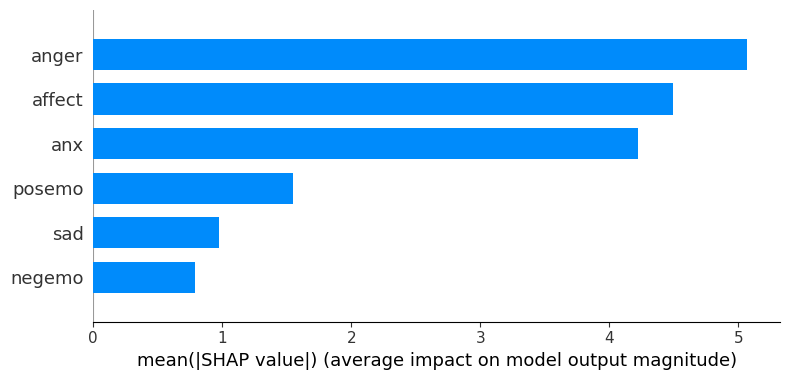

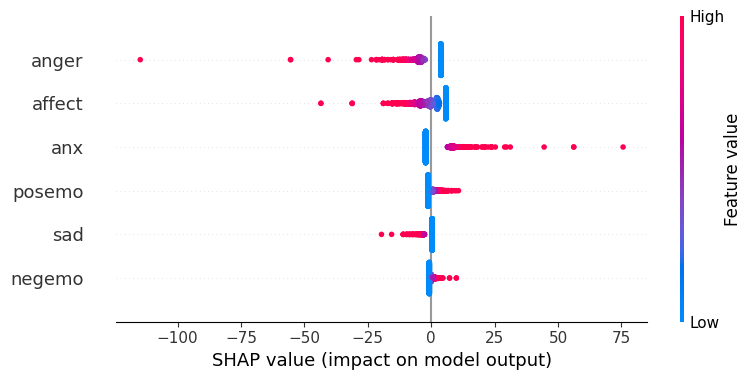

Saved SHAP plots for anx:
  /content/drive/MyDrive/submission/hybrid_submission/interpretability/lex_shap_anx_bar.png
  /content/drive/MyDrive/submission/hybrid_submission/interpretability/lex_shap_anx_swarm.png


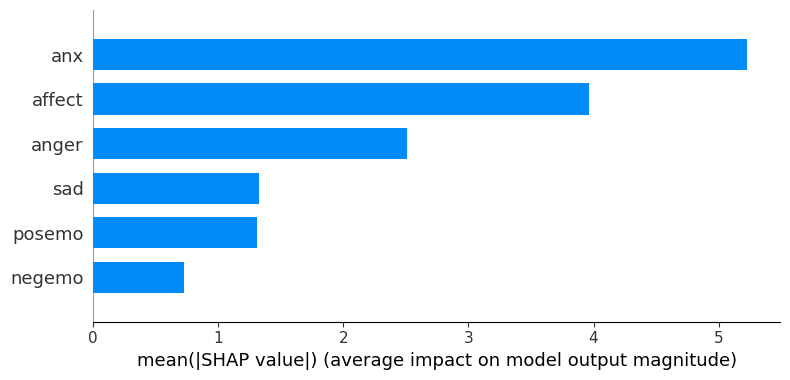

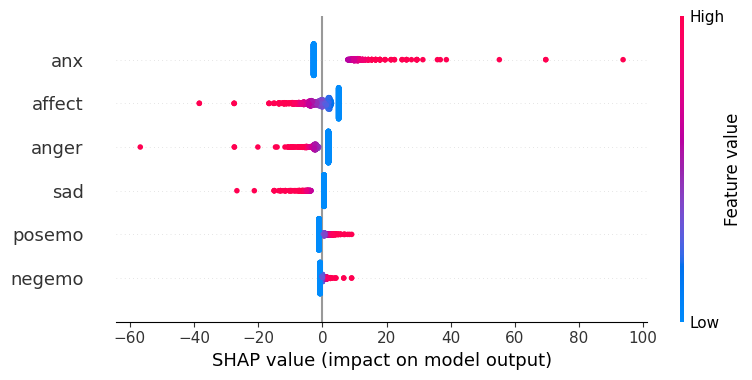

Saved SHAP plots for anger:
  /content/drive/MyDrive/submission/hybrid_submission/interpretability/lex_shap_anger_bar.png
  /content/drive/MyDrive/submission/hybrid_submission/interpretability/lex_shap_anger_swarm.png


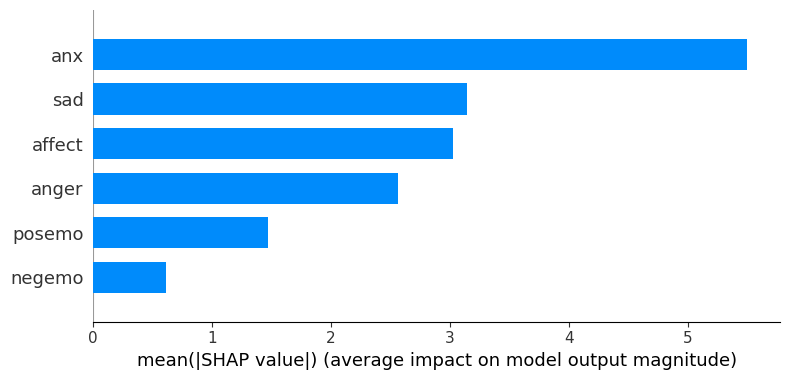

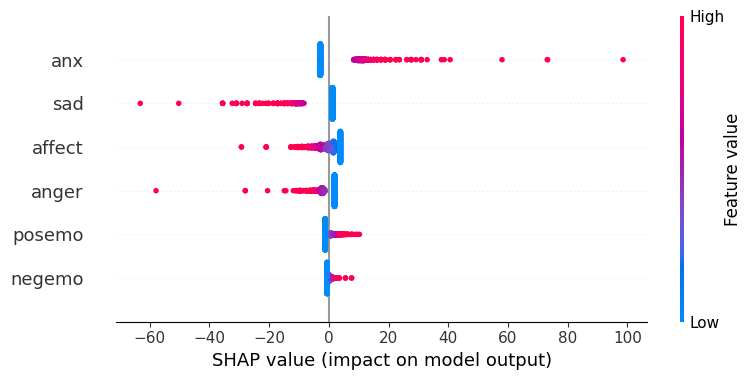

Saved SHAP plots for sad:
  /content/drive/MyDrive/submission/hybrid_submission/interpretability/lex_shap_sad_bar.png
  /content/drive/MyDrive/submission/hybrid_submission/interpretability/lex_shap_sad_swarm.png


In [31]:
import shap
import matplotlib.pyplot as plt

out_dir_int = os.path.join(config.out_dir, "interpretability")
os.makedirs(out_dir_int, exist_ok=True)

def shap_for_lexicon_label(label: str, df: pd.DataFrame, max_bg: int = 500, max_eval: int = 1000):

    pred_col = label_map[f"label_{label}"]
    liwc_features = list(config.liwc_cols)
    _require_cols(df, ["text", pred_col] + liwc_features, "df_for_shap")

    model = lex_models[label]

    mask = df[pred_col].notna()
    x = df.loc[mask, liwc_features].copy()
    x = x.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    if x.shape[0] == 0:
        print(f" {label}: no rows after dropping NaNs")
        return

    # background & evaluation samples
    x_bg = x.sample(min(max_bg, len(x)), random_state=42)
    x_ev = x.sample(min(max_eval, len(x)), random_state=43)

    # model is CalibratedClassifierCV, which contains a Pipeline, and the LogisticRegression is the last step in the pipeline
    linear_model = model.estimator.steps[-1][1]

    # LinearExplainer for logistic regression models
    explainer = shap.LinearExplainer(linear_model, x_bg, feature_perturbation="interventional")
    shap_values = explainer.shap_values(x_ev)

    # Plots
    plt.figure()
    shap.summary_plot(shap_values, x_ev, plot_type="bar", show=False, max_display=20)
    path_bar = os.path.join(out_dir_int, f"lex_shap_{label}_bar.png")
    plt.tight_layout()
    plt.savefig(path_bar, dpi=180)
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, x_ev, show=False, max_display=20)
    path_swarm = os.path.join(out_dir_int, f"lex_shap_{label}_swarm.png")
    plt.tight_layout()
    plt.savefig(path_swarm, dpi=180)
    plt.show()

    print(f"Saved SHAP plots for {label}:")
    print(" ", path_bar)
    print(" ", path_swarm)

for label in labels:
    shap_for_lexicon_label(label, test_full)

In [ ]:
 #!pip install captum

In [32]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
roberta.to(device)
roberta.eval()

label2idx = {label: i for i, label in enumerate(labels)}

def _force_eager_attention(model):
    try:
        model.config.attn_implementation = "eager"
    except Exception:
        pass

    return model

def attention_top_tokens(text: str, top_k: int = 15, max_length: int = 256, retry_with_eager: bool = True):
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    def _run_forward():
        with torch.no_grad():
            return roberta(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=True,
                return_dict=True
            )

    out = _run_forward()

    attentions = getattr(out, "attentions", None)

    attn_last = attentions[-1][0]        # [heads, seq, seq]
    attn_mean = attn_last.mean(dim=0)    # [seq, seq]

    scores = attn_mean.sum(dim=0).detach().cpu().numpy()  # [seq]

    toks = tokenizer.convert_ids_to_tokens(input_ids[0].detach().cpu().tolist())

    pairs = []
    for t, s in zip(toks, scores):
        if t in [tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token]:
            continue
        pairs.append((t, float(s)))

    pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)[:top_k]

    print(f"\nText: {text[:200]}{'...' if len(text) > 200 else ''}")
    print("Top tokens by attention :")
    for t, s in pairs_sorted:
        print(f"{t:>15s}  {s:.5f}")

example_row = test_full.loc[test_full["text"].notna()].sample(1, random_state=1).iloc[0]
attention_top_tokens(example_row["text"], top_k=12)


Text: RT @muslimvoices: After Charlie Hebdo shooting, Muslims seek safe space to talk extremism http://t.co/b95yGSkSp7 (via @TheCurrentCBC) // rp
Top tokens by attention :
         ĠHebdo  3.67541
     Ġextremism  2.80040
       ĠMuslims  1.80498
            mus  1.76597
      Ġshooting  1.44142
          Ġtalk  1.38609
              :  1.29350
             Ġr  1.22906
              p  1.20870
             co  1.17268
              ,  1.16778
             Ġ@  1.15347


In [33]:
from sklearn.linear_model import LogisticRegression

def train_hybridA_meta_2feat(val_df: pd.DataFrame, label: str):
    pred_col = label_map[f"label_{label}"]
    roberta_col = f"roberta_{label}_prob"
    lex_col = f"lex_{label}_prob"

    _require_cols(val_df, [pred_col, roberta_col, lex_col], "val_full")

    mask = val_df[pred_col].notna() & val_df[roberta_col].notna() & val_df[lex_col].notna()
    x = val_df.loc[mask, [roberta_col, lex_col]].to_numpy(dtype=float)
    y = val_df.loc[mask, pred_col].astype(int).to_numpy()

    meta = LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=1000,
        class_weight="balanced", random_state=42
    )
    meta.fit(x, y)
    return meta

hyA_route_rows = []
hyA_meta = {}

for label in labels:
    meta = train_hybridA_meta_2feat(val_full, label)
    hyA_meta[label] = meta

    pred_col = label_map[f"label_{label}"]
    roberta_col = f"roberta_{label}_prob"
    lex_col = f"lex_{label}_prob"

    mask = test_full[pred_col].notna() & test_full[roberta_col].notna() & test_full[lex_col].notna()

    weight_r, weight_l = meta.coef_[0][0], meta.coef_[0][1]
    b = float(meta.intercept_[0])

    roberta_prob = test_full.loc[mask,roberta_col].to_numpy(dtype=float)
    lex_prob= test_full.loc[mask, lex_col].to_numpy(dtype=float)

    contrib_r = weight_r * roberta_prob
    contrib_l = weight_l * lex_prob
    route = np.where(contrib_r >= contrib_l, "roberta", "lexicon")

    df_data = {
        "label": label,
        "route": route,
        "domain": test_full.loc[mask, "domain"].values ,
        "text_len": test_full.loc[mask, "text"].apply(word_len).values,
        "roberta_prob":roberta_prob,
        "lex_prob": lex_prob,
        "contrib_roberta": contrib_r,
        "contrib_lexicon":contrib_l,
        "bias":b
    }
    if "dataset_name" in test_full.columns:
        df_data["dataset_name"] = test_full.loc[mask, "dataset_name"].values

    hyA_route_rows.append(pd.DataFrame(df_data))

hyA_route_df = pd.concat(hyA_route_rows, ignore_index=True)
hyA_route_df.head()

,label,route,domain,text_len,roberta_prob,lex_prob,contrib_roberta,contrib_lexicon,bias
0,anx,lexicon,terror_attack,31,0.001135,0.009461,0.009255,0.072105,-3.383855
1,anx,lexicon,terror_attack,20,0.001716,0.006924,0.013987,0.052774,-3.383855
2,anx,lexicon,terror_attack,6,0.001476,0.238095,0.012037,1.814653,-3.383855
3,anx,lexicon,terror_attack,0,0.001402,0.042917,0.011428,0.327095,-3.383855
4,anx,lexicon,terror_attack,22,0.001336,0.044790,0.010892,0.341367,-3.383855


In [34]:
hyB_route_rows = []

for label in labels:
    y_col = label_map[f"label_{label}"]
    roberta_col = f"roberta_{label}_prob"
    lex_col = f"lex_{label}_prob"

    thr = hyB_thr[label]
    mask = test_full[y_col].notna() & test_full[roberta_col].notna() & test_full[lex_col].notna()

    roberta_prob = test_full.loc[mask, roberta_col].to_numpy(dtype=float)
    lex_prob = test_full.loc[mask, lex_col].to_numpy(dtype=float)

    use_roberta = roberta_prob >= thr
    route = np.where(use_roberta, "roberta", "lexicon")

    df_data = {
        "label": label,
        "route": route,
        "threshold": float(thr),
        "domain": test_full.loc[mask, "domain"].values,
        "text_len": test_full.loc[mask, "text"].apply(word_len).values,
        "roberta_prob": roberta_prob,
        "lex_prob": lex_prob
    }
    if "dataset_name" in test_full.columns:
        df_data["dataset_name"] = test_full.loc[mask, "dataset_name"].values

    hyB_route_rows.append(pd.DataFrame(df_data))

hyB_route_df = pd.concat(hyB_route_rows, ignore_index=True)
hyB_route_df.head()

,label,route,threshold,domain,text_len,roberta_prob,lex_prob
0,anx,lexicon,0.4,terror_attack,31,0.001135,0.009461
1,anx,lexicon,0.4,terror_attack,20,0.001716,0.006924
2,anx,lexicon,0.4,terror_attack,6,0.001476,0.238095
3,anx,lexicon,0.4,terror_attack,0,0.001402,0.042917
4,anx,lexicon,0.4,terror_attack,22,0.001336,0.044790
